# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [2]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## read *.csv file
FILE_PATH = "ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"
df = pd.read_csv(FILE_PATH)

## filter to a smaller dataset do at top so below are all this
towns_to_keep = ['PUNGGOL', 'SENGKANG', 'HOUGANG']
## drop all towns not in the list of towns to keep
df = df[df['town'].isin(towns_to_keep)].reset_index(drop=True)

df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,HOUGANG,2 ROOM,986A,BUANGKOK CRES,10 TO 12,47.0,Model A,2012,94 years 04 months,252000.0
1,2017-01,HOUGANG,3 ROOM,22,HOUGANG AVE 3,01 TO 03,73.0,New Generation,1978,60 years 04 months,260000.0
2,2017-01,HOUGANG,3 ROOM,644,HOUGANG AVE 8,01 TO 03,60.0,Improved,1987,69 years,268000.0
3,2017-01,HOUGANG,3 ROOM,24,HOUGANG AVE 3,01 TO 03,67.0,New Generation,1978,60 years 05 months,269000.0
4,2017-01,HOUGANG,3 ROOM,108,HOUGANG AVE 1,01 TO 03,67.0,New Generation,1984,66 years 03 months,270000.0
...,...,...,...,...,...,...,...,...,...,...,...
47859,2026-05,SENGKANG,EXECUTIVE,102,RIVERVALE WALK,16 TO 18,144.0,Apartment,1999,71 years 11 months,970000.0
47860,2026-05,SENGKANG,EXECUTIVE,102,RIVERVALE WALK,13 TO 15,141.0,Apartment,1999,71 years 10 months,930000.0
47861,2026-06,SENGKANG,EXECUTIVE,103,RIVERVALE WALK,04 TO 06,143.0,Maisonette,1999,71 years 10 months,886000.0
47862,2026-03,SENGKANG,EXECUTIVE,202B,SENGKANG EAST RD,13 TO 15,130.0,Apartment,2001,74 years 02 months,875000.0


## 2.2 Summary Statistics

In [4]:

## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47864 entries, 0 to 47863
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                47864 non-null  object 
 1   town                 47864 non-null  object 
 2   flat_type            47864 non-null  object 
 3   block                47864 non-null  object 
 4   street_name          47864 non-null  object 
 5   storey_range         47864 non-null  object 
 6   floor_area_sqm       47864 non-null  float64
 7   flat_model           47864 non-null  object 
 8   lease_commence_date  47864 non-null  int64  
 9   remaining_lease      47864 non-null  object 
 10  resale_price         47864 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 4.0+ MB


In [5]:
## Check for missing data
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [6]:
## Describe data distribution
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,47864.000000,47864.000000,4.786400e+04
mean,97.777453,2006.612903,5.362435e+05
std,19.357725,10.588648,1.414658e+05
min,37.000000,1975.000000,1.950000e+05
25%,92.000000,2001.000000,4.300000e+05
50%,93.000000,2012.000000,5.200000e+05
75%,111.000000,2015.000000,6.280000e+05
max,177.000000,2022.000000,1.470000e+06


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

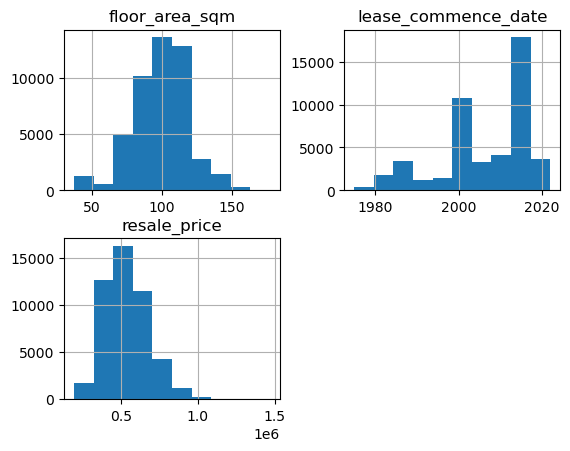

In [7]:
## Understanding distribution of features
df.hist()
## Understanding distribution of target
# Target = resale_price. A histogram shows its shape (e.g. skew, common price range).
sns.histplot(df['resale_price'], kde=True)
plt.title('Distribution of Resale Price')
plt.xlabel('Resale Price ($)')
plt.ylabel('Count')
plt.show()

### 2.3.1.2 Understanding distribution of features

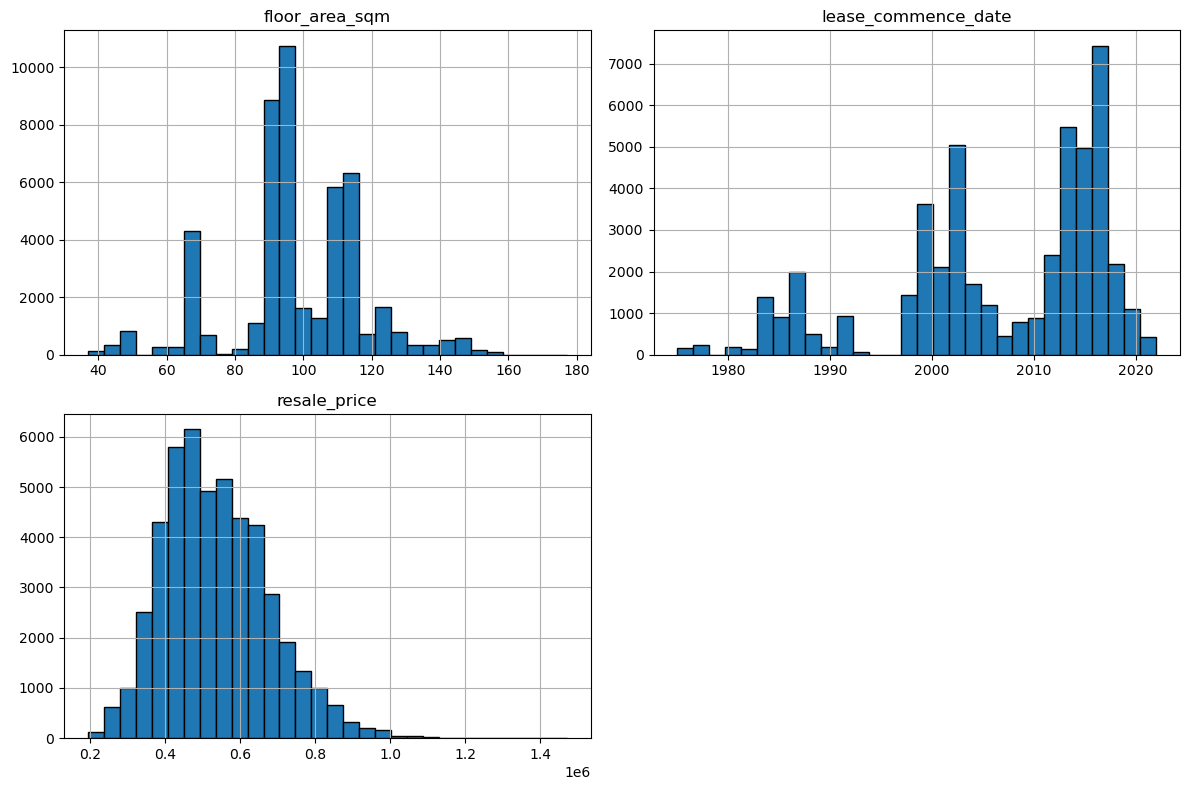

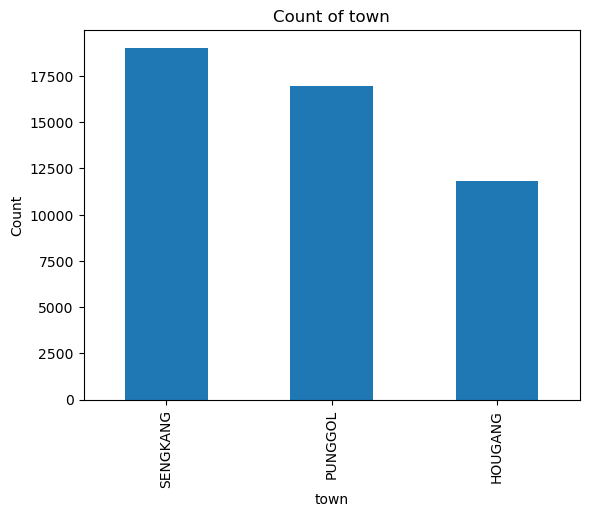

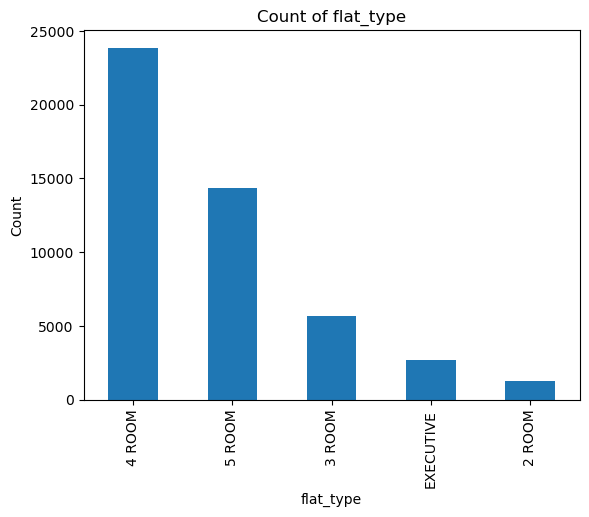

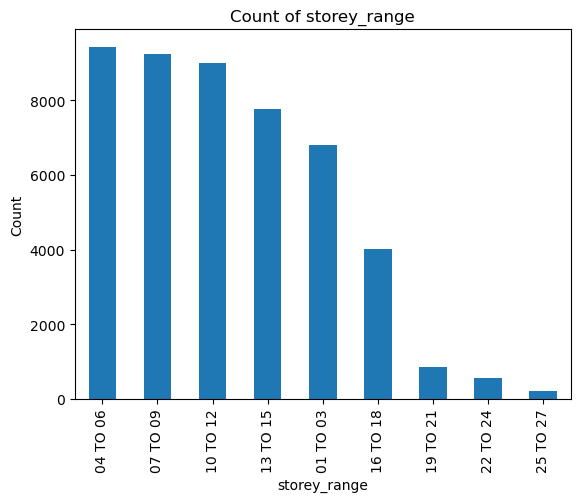

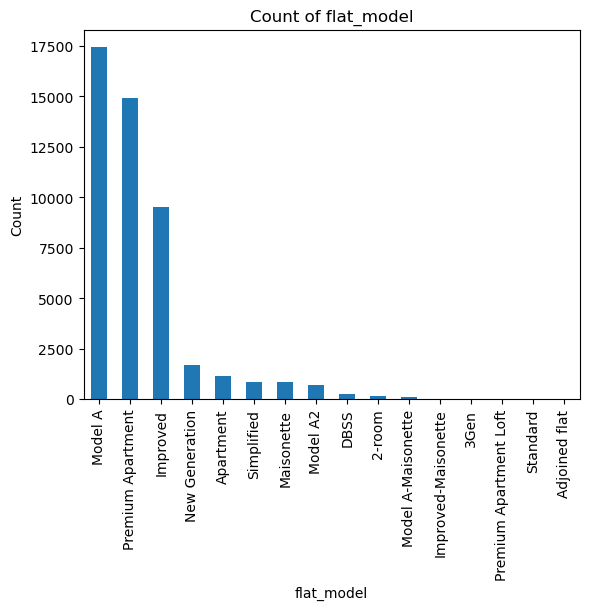

In [8]:
# numeric features: histogram of each
df.hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()

# categorical features: count of each category
categorical_cols = ['town', 'flat_type', 'storey_range', 'flat_model']
for col in categorical_cols:
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

### 2.3.2 Understanding relationship between variables

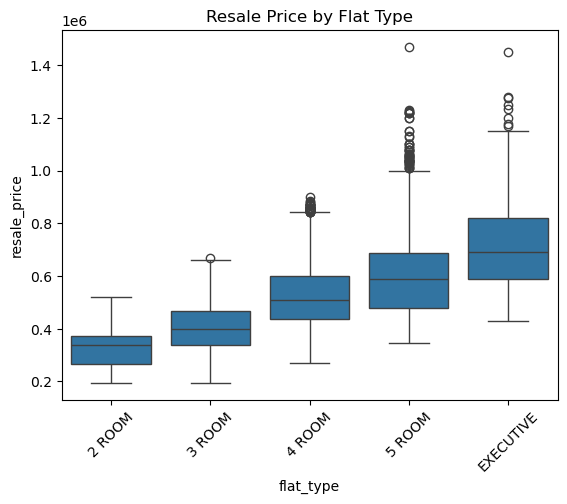

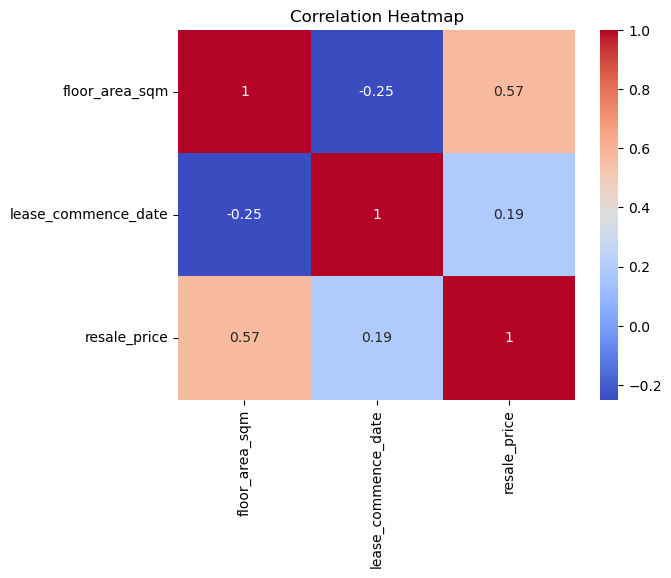

In [9]:
# Categorical feature vs target: price spread per flat type
sns.boxplot(data=df, x='flat_type', y='resale_price')
plt.title('Resale Price by Flat Type')
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap between the numeric columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [10]:
## Clean data
# df is already filtered to our chosen towns at load time (section 2.1)
df_clean = df.copy()

# 'remaining_lease' is text like "61 years 04 months" -> convert to a numeric value in years
def parse_lease(text):
    parts = text.split()
    years = months = 0
    for i, p in enumerate(parts):
        if p.startswith('year'):
            years = int(parts[i - 1])
        elif p.startswith('month'):
            months = int(parts[i - 1])
    return years + months / 12

df_clean['remaining_lease_years'] = df_clean['remaining_lease'].apply(parse_lease)

# 'month' is text like "2017-01" -> pull out the year as a number
df_clean['year'] = df_clean['month'].str[:4].astype(int)

# Drop columns we won't use as features:
#  - month / remaining_lease: replaced by the numeric versions above
#  - block / street_name: too many unique values (high cardinality) to be useful
df_clean = df_clean.drop(columns=['month', 'remaining_lease', 'block', 'street_name'])

df_clean.head()

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease_years,year
0,HOUGANG,2 ROOM,10 TO 12,47.0,Model A,2012,252000.0,94.333333,2017
1,HOUGANG,3 ROOM,01 TO 03,73.0,New Generation,1978,260000.0,60.333333,2017
2,HOUGANG,3 ROOM,01 TO 03,60.0,Improved,1987,268000.0,69.000000,2017
3,HOUGANG,3 ROOM,01 TO 03,67.0,New Generation,1978,269000.0,60.416667,2017
4,HOUGANG,3 ROOM,01 TO 03,67.0,New Generation,1984,270000.0,66.250000,2017


In [11]:
## Clean data
# df is already filtered to our chosen towns at load time (section 2.1)
df_clean = df.copy()

# 'remaining_lease' is text like "61 years 04 months" -> convert to a numeric value in years
def parse_lease(text):
    parts = text.split()
    years = months = 0
    for i, p in enumerate(parts):
        if p.startswith('year'):
            years = int(parts[i - 1])
        elif p.startswith('month'):
            months = int(parts[i - 1])
    return years + months / 12

df_clean['remaining_lease_years'] = df_clean['remaining_lease'].apply(parse_lease)

# 'month' is text like "2017-01" -> months elapsed since the start of the data.
# Prices rose ~50% over this period, and a plain year number would lose the
# movement within each year.
sale_date = pd.to_datetime(df_clean['month'])
df_clean['months_since_2017'] = (sale_date.dt.year - 2017) * 12 + (sale_date.dt.month - 1)

# 'storey_range' is text like "10 TO 12" -> take the middle floor as a number.
# One-hot encoding would lose the fact that higher floors are higher.
df_clean['storey_mid'] = (
    df_clean['storey_range']
    .str.split(' TO ')
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2)
)

# 'flat_model' has one inconsistently-cased value, plus a few categories with
# too few rows to learn from -> group those into 'Other' (6 categories, 198 rows)
df_clean['flat_model'] = df_clean['flat_model'].replace({'2-room': '2-Room'})
model_counts = df_clean['flat_model'].value_counts()
rare_models = model_counts[model_counts < 100].index
df_clean['flat_model'] = df_clean['flat_model'].where(
    ~df_clean['flat_model'].isin(rare_models), 'Other'  #SHOULD I DO THIS THO OR SHOULD I JUST DROP OR TAKE INTO CONSIDERATION IDK LEH
)

# Drop columns we won't use as features:
#  - month / remaining_lease / storey_range: replaced by the numeric versions above
#  - block: 1430 unique values, and the number alone means nothing across streets
#  - lease_commence_date: = 99 - (sale date - remaining_lease_years), so the two
#    columns above already contain it
df_clean = df_clean.drop(columns=[
    'month', 'remaining_lease', 'storey_range', 'block', 'lease_commence_date'
])

df_clean.head()


,town,flat_type,street_name,floor_area_sqm,flat_model,resale_price,remaining_lease_years,months_since_2017,storey_mid
0,HOUGANG,2 ROOM,BUANGKOK CRES,47.0,Model A,252000.0,94.333333,0,11.0
1,HOUGANG,3 ROOM,HOUGANG AVE 3,73.0,New Generation,260000.0,60.333333,0,2.0
2,HOUGANG,3 ROOM,HOUGANG AVE 8,60.0,Improved,268000.0,69.000000,0,2.0
3,HOUGANG,3 ROOM,HOUGANG AVE 3,67.0,New Generation,269000.0,60.416667,0,2.0
4,HOUGANG,3 ROOM,HOUGANG AVE 1,67.0,New Generation,270000.0,66.250000,0,2.0


## 3.2 Train-Test Split

In [12]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

#seperate target variable from features
X = df_clean.drop(columns=['resale_price'])
y = df_clean['resale_price']

# One-hot encode the categorical columns
X = pd.get_dummies(X, columns=['town', 'flat_type', 'street_name', 'flat_model'])

# Save the column list -- the app needs it to line its input up with the model
model_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (38291, 96) | Test: (9573, 96)


# 4. Modelling

### 4.2 Train Model

In [13]:
## Initialise and train model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# 5. Model Evaluation

In [14]:
## Evaluate model
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)
print('R2 :', round(r2_score(y_test, y_pred), 4))
print('MAE:', round(mean_absolute_error(y_test, y_pred)))

R2 : 0.9665
MAE: 18837


In [15]:
## New data

## Predict
## New data
new_flat = pd.DataFrame([{
    'town': 'PUNGGOL',
    'flat_type': '4 ROOM',
    'street_name': 'PUNGGOL DR',
    'floor_area_sqm': 93.0,
    'flat_model': 'Model A',
    'remaining_lease_years': 90.0,
    'months_since_2017': 108,
    'storey_mid': 11.0,
}])

# get_dummies on one row only builds the 8 columns that row uses, so reindex
# fills the missing 88 with 0 and puts them in the order the model trained on
new_flat = pd.get_dummies(new_flat)
new_flat = new_flat.reindex(columns=model_columns, fill_value=0)

## Predict
print(model.predict(new_flat))


[665366.58]


## Iterative model development


In [ ]:
## Further feature engineering / feature selection